# ARIA v2.0 - 避難收容所地形複合風險評估系統

**專案概述**：
本系統旨在升級第一代 ARIA 系統，導入內政部 20m DEM 高程網格資料。除了既有的河川距離評估外，額外加入「平均高程」與「最大坡度」等地形情報，為花蓮縣的避難收容處所建立更完善的複合風險分級模型。

### 👨‍✈️ Captain's Log: Stardate 1.0 - 系統初始化
**任務目標**：載入 ARIA 系統運作所需的所有空間分析模組（GeoPandas, Rasterio, Rioxarray 等），並讀取 `.env` 中的環境變數與風險門檻值，確保後續運算邏輯的一致性。

In [6]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import fiona
from shapely.geometry import Point
from dotenv import load_dotenv

# 載入 .env 檔案中的設定（用來管理潛在的機密路徑或 API Key）
load_dotenv()

print("✅ 所有套件匯入成功！")
print(f"GeoPandas 版本: {gpd.__version__}")
print(f"Rasterio 版本: {rasterio.__version__}")

✅ 所有套件匯入成功！
GeoPandas 版本: 1.1.2
Rasterio 版本: 1.5.0


### 👨‍✈️ Captain's Log: Stardate 2.0 - 空間資料介接與 CRS 校準
**任務目標**：載入水利署河川面、鄉鎮市區界、避難所點位（向量）以及 20m DEM（網格）。
**關鍵行動**：將所有異質資料的座標系統（Coordinate Reference System）強制統一投影至台灣二度分帶座標 **EPSG:3826**，為後續的精確距離與面積計算打下基礎。

In [8]:
print("=== 開始載入 GIS 資料與統一座標系統 (EPSG:3826) ===")

# ==========================================
# 1. 載入水利署河川資料 (Vector)
# ==========================================
rivers_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Exercise 3-Geopandas\riverpoly\RIVERPOLY.shp"
rivers_gdf = gpd.read_file(rivers_path)
rivers_gdf = rivers_gdf.to_crs("EPSG:3826")
print(f"✅ 1. 河川資料載入完成！數量: {len(rivers_gdf)} 筆, CRS: {rivers_gdf.crs}")

# ==========================================
# 2. 載入鄉鎮市區界 (Vector) - [已更新為解壓縮後的絕對路徑]
# ==========================================
townships_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework3\data\TOWN_MOI_FULL_TAIWAN_1140318\TOWN_MOI_1140318.shp"
try:
    townships_gdf = gpd.read_file(townships_path)
    townships_gdf = townships_gdf.to_crs("EPSG:3826")
    print(f"✅ 2. 鄉鎮市區界載入完成！數量: {len(townships_gdf)} 筆, CRS: {townships_gdf.crs}")
except Exception as e:
    print(f"❌ 2. 讀取鄉鎮市區界失敗: {e}")

# ==========================================
# 3. 載入並轉換避難所資料 (CSV to Vector)
# ==========================================
shelters_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\0303_Exercise2\aqi-analysis\data\shelters_cleaned.csv"
# 讀取 CSV 並移除沒有經緯度的空值資料
shelters_df = pd.read_csv(shelters_path).dropna(subset=['經度', '緯度'])

# 將 DataFrame 轉為 GeoDataFrame (初始為 WGS84: EPSG:4326)
shelters_gdf = gpd.GeoDataFrame(
    shelters_df, 
    geometry=gpd.points_from_xy(shelters_df['經度'], shelters_df['緯度']),
    crs="EPSG:4326"
)
# 轉換為 TWD97 (EPSG:3826) 以便計算公尺距離
shelters_gdf = shelters_gdf.to_crs("EPSG:3826")
print(f"✅ 3. 避難所資料轉換完成！數量: {len(shelters_gdf)} 筆, CRS: {shelters_gdf.crs}")

# ==========================================
# 4. 載入 DEM 高程資料 (Raster)
# ==========================================
dem_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework4\dem_20m_hualien.tif"
try:
    dem_src = rasterio.open(dem_path)
    print(f"✅ 4. DEM 高程資料載入完成！大小: {dem_src.width}x{dem_src.height}, CRS: {dem_src.crs}")
except Exception as e:
    print(f"❌ 4. DEM 載入失敗: {e}")

print("\n🎉 Cell 2 執行完畢！所有基礎資料已備妥。")

=== 開始載入 GIS 資料與統一座標系統 (EPSG:3826) ===
✅ 1. 河川資料載入完成！數量: 13262 筆, CRS: EPSG:3826
✅ 2. 鄉鎮市區界載入完成！數量: 368 筆, CRS: EPSG:3826
✅ 3. 避難所資料轉換完成！數量: 5764 筆, CRS: EPSG:3826
✅ 4. DEM 高程資料載入完成！大小: 3997x7054, CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

🎉 Cell 2 執行完畢！所有基礎資料已備妥。


### 👨‍✈️ Captain's Log: Stardate 3.0 - 目標區域防呆檢查 (Sanity Check)
**任務目標**：在進行大規模運算前，驗證水利署的河川面資料是否確實涵蓋我們的目標行動區域（花蓮縣）。
**關鍵行動**：利用 `gpd.sjoin` 檢查交集，若結果為 0 將觸發斷言（Assert）警報中止程式，避免後續產出無效報表。

In [9]:
print("=== 開始執行空間分析：高程擷取與河川距離計算 ===")

# --------------------------------------------------
# 1. 從 DEM 擷取避難所高程 (Point to Raster)
# --------------------------------------------------
print("\n[分析 1] 正在從 DEM 擷取高程...")
# 確保座標系統字串完全一致 (將避難所暫時對齊 DEM 的詳細 CRS 格式)
if shelters_gdf.crs != dem_src.crs:
    shelters_for_dem = shelters_gdf.to_crs(dem_src.crs)
else:
    shelters_for_dem = shelters_gdf

# 取出所有避難所的 X, Y 座標對
coords = [(geom.x, geom.y) for geom in shelters_for_dem.geometry]

try:
    # dem_src.sample 會根據座標去讀取像素值
    elevations = [val[0] for val in dem_src.sample(coords)]
    shelters_gdf['Elevation_m'] = elevations
    print("✅ 高程擷取完成！(已新增 'Elevation_m' 欄位)")
except Exception as e:
    print(f"❌ 高程擷取失敗：{e}")

# --------------------------------------------------
# 2. 計算避難所與最近河川的距離 (Nearest Neighbor)
# --------------------------------------------------
print("\n[分析 2] 正在計算避難所與最近河川的距離...")
try:
    # 使用 sjoin_nearest 尋找最近的河川，並自動算出距離
    # 因為我們已經轉成 EPSG:3826，算出來的距離單位就是「公尺」
    shelters_with_river = gpd.sjoin_nearest(
        shelters_gdf, 
        rivers_gdf, 
        how="left", 
        distance_col="dist_to_river_m"
    )
    
    # 若一個避難所同時離多條河川一樣近，會產生重複列，這裡保留第一筆即可
    shelters_with_river = shelters_with_river[~shelters_with_river.index.duplicated(keep='first')]
    
    # 將算好的距離更新回原本的 DataFrame
    shelters_gdf['dist_to_river_m'] = shelters_with_river['dist_to_river_m']
    print("✅ 河川距離計算完成！(已新增 'dist_to_river_m' 欄位)")
except Exception as e:
    print(f"❌ 距離計算發生錯誤：{e}")

# --------------------------------------------------
# 3. 檢視成果
# --------------------------------------------------
print("\n=== 分析結果預覽 ===")
# 顯示新增的欄位檢查結果
display(shelters_gdf[['經度', '緯度', 'Elevation_m', 'dist_to_river_m']].head())

=== 開始執行空間分析：高程擷取與河川距離計算 ===

[分析 1] 正在從 DEM 擷取高程...
✅ 高程擷取完成！(已新增 'Elevation_m' 欄位)

[分析 2] 正在計算避難所與最近河川的距離...
✅ 河川距離計算完成！(已新增 'dist_to_river_m' 欄位)

=== 分析結果預覽 ===


,經度,緯度,Elevation_m,dist_to_river_m
0,118.248571,24.428328,-32767.0,206775.344375
1,121.056100,24.672500,-32767.0,3.310944
2,119.453178,24.988739,-32767.0,130790.652897
3,121.351987,24.820601,-32767.0,210.172745
4,121.334302,24.797047,-32767.0,192.329098


### 👨‍✈️ Captain's Log: Stardate 4.0 - 空間交集與資料清洗
**任務目標**：將全國避難所資料過濾，僅保留位於目標區域（花蓮縣）內的設施。
**關鍵行動**：透過 `how="inner"` 的空間交集操作，同時完成資料篩選並為避難所貼上所屬鄉鎮市區（TOWNNAME）的屬性標籤。並確保核心識別欄位（序號、名稱、geometry）完好保留。

In [10]:
print("=== 開始執行防呆檢查 (Sanity Check) ===")

# 1. 設定你的目標縣市
target_county = "花蓮縣"

# 2. 從全台鄉鎮市區界 (townships_gdf) 中過濾出目標縣市
# 備註：內政部的 shapefile 縣市欄位通常叫 'COUNTYNAME'。如果不對，系統會報錯，我們再來查欄位名稱。
try:
    county_boundary = townships_gdf[townships_gdf['COUNTYNAME'] == target_county]
    print(f"✅ 成功篩選出 {target_county} 的邊界資料，包含 {len(county_boundary)} 個鄉鎮市區。")
except KeyError:
    print("❌ 找不到 'COUNTYNAME' 欄位，請印出 townships_gdf.columns 確認正確的縣市欄位名稱。")

# 3. 執行指引中的防呆檢查
print("\n正在計算河川與目標縣市的交集...")
# 將指引的變數名稱替換成我們前面定義好的 rivers_gdf
rivers_in_county = gpd.sjoin(rivers_gdf, county_boundary, predicate='intersects')

print(f"👉 河川面與 {target_county} 交集：{len(rivers_in_county)} 筆")

# 4. 斷言檢查 (Assert)：如果結果為 0，程式會在這裡立刻中斷並報錯
assert len(rivers_in_county) > 0, f"⚠️ 河川資料未涵蓋 {target_county}！請重新下載完整河川資料，不要篩選前 N 條"

print("🎉 防呆檢查通過！你的河川資料確實涵蓋了目標縣市，可以安心繼續分析。")

=== 開始執行防呆檢查 (Sanity Check) ===
✅ 成功篩選出 花蓮縣 的邊界資料，包含 13 個鄉鎮市區。

正在計算河川與目標縣市的交集...
👉 河川面與 花蓮縣 交集：738 筆
🎉 防呆檢查通過！你的河川資料確實涵蓋了目標縣市，可以安心繼續分析。


### 👨‍✈️ Captain's Log: Stardate 5.0 - 地形情報萃取 (Terrain Analysis)
**任務目標**：結合 20m DEM 高程網格，為每個避難所周圍建立 500 公尺的緩衝區（Buffer），評估其面臨的地形威脅。
**關鍵行動**：利用 `numpy.gradient` 計算地表坡度，並透過 `zonal_stats` 提取各緩衝區內的「平均高程」與「最大坡度」。

In [18]:
print("=== 開始執行空間交集：標註避難所所在鄉鎮 ===")

try:
    # 1. 將避難所與花蓮縣鄉鎮邊界進行空間交集
    shelters_hualien = gpd.sjoin(
        shelters_gdf, 
        county_boundary, 
        how="inner", 
        predicate="intersects"
    )
    
    # 2. 整理最終欄位 (把 '序號' 和 '避難收容處所名稱' 救回來！)
    cols_to_keep = [
        '序號', '避難收容處所名稱', 
        '經度', '緯度', 'Elevation_m', 'dist_to_river_m', 'TOWNNAME', 'geometry'
    ] 
    
    # 確保只留下存在的欄位，避免報錯
    final_cols = [col for col in cols_to_keep if col in shelters_hualien.columns]
    
    # 確保產出的是 GeoDataFrame
    shelters_final = gpd.GeoDataFrame(
        shelters_hualien[final_cols].copy(), 
        geometry='geometry',
        crs="EPSG:3826"
    )
    
    print(f"✅ 成功完成空間交集！")
    print(f"👉 篩選後，位於花蓮縣的避難所共有：{len(shelters_final)} 個")

except Exception as e:
    print(f"❌ 空間交集發生錯誤：{e}")

=== 開始執行空間交集：標註避難所所在鄉鎮 ===
✅ 成功完成空間交集！
👉 篩選後，位於花蓮縣的避難所共有：190 個


### 👨‍✈️ Captain's Log: Stardate 6.0 - 複合風險判定 (Composite Risk)
**任務目標**：將單一的物理距離轉化為具備地形脈絡的立體風險模型。
**關鍵行動**：依據 `.env` 設定的門檻（距河川距離、坡度 > 30 度、高程 < 50m），使用 `numpy.select` 執行多條件邏輯判斷，將設施分為「極高、高、中、低」四個風險等級。

In [19]:
import os
import numpy as np
import rioxarray
from rasterstats import zonal_stats

print("=== 開始執行進階地形分析 (Terrain Analysis) ===")

# 1. 從 .env 讀取門檻值
SLOPE_THRESHOLD = float(os.getenv('SLOPE_THRESHOLD', 30))
ELEVATION_LOW = float(os.getenv('ELEVATION_LOW', 50))
BUFFER_HIGH = float(os.getenv('BUFFER_HIGH', 500))

# 2. 使用 rioxarray 讀取 DEM
print("\n[載入 DEM 與計算坡度]")
dem_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework4\dem_20m_hualien.tif"
dem_rx = rioxarray.open_rasterio(dem_path)
transform = dem_rx.rio.transform()
nodata_val = dem_rx.rio.nodata

# 3. 計算坡度 (Slope)
# 指引要求：np.gradient 的第二個參數是像素解析度 (20m)
dy, dx = np.gradient(dem_rx.values[0], 20)
slope_array = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
print("✅ 坡度計算完成！")

# 4. 建立 500m 緩衝區 (Buffer)
print(f"\n[建立 {int(BUFFER_HIGH)}m 緩衝區與計算 Zonal Stats]")
# 使用前面已經處理好的 shelters_final (已在花蓮縣境內)
buffers = shelters_final.geometry.buffer(BUFFER_HIGH)

# 5. 執行 Zonal Statistics (高程)
elev_stats = zonal_stats(
    buffers,
    dem_rx.values[0],
    affine=transform,
    nodata=nodata_val,
    stats="mean std"
)

# 6. 執行 Zonal Statistics (坡度)
# 將 DEM 的 nodata 區域在坡度矩陣中也設為 NaN，避免計算錯誤
slope_array_clean = np.where(dem_rx.values[0] == nodata_val, np.nan, slope_array)
slope_stats = zonal_stats(
    buffers,
    slope_array_clean,
    affine=transform,
    nodata=np.nan,
    stats="max"
)

# 7. 將計算結果合併回避難所資料表
shelters_final['mean_elevation'] = [stat['mean'] for stat in elev_stats]
shelters_final['std_elevation'] = [stat['std'] for stat in elev_stats]
shelters_final['max_slope'] = [stat['max'] for stat in slope_stats]

print("✅ Zonal Statistics 計算完畢！")

# 檢視成果
display(shelters_final[['經度', '緯度', 'dist_to_river_m', 'mean_elevation', 'max_slope']].head())

=== 開始執行進階地形分析 (Terrain Analysis) ===

[載入 DEM 與計算坡度]
✅ 坡度計算完成！

[建立 500m 緩衝區與計算 Zonal Stats]
✅ Zonal Statistics 計算完畢！


,經度,緯度,dist_to_river_m,mean_elevation,max_slope
28,121.748879,24.308073,865.673162,27.502352,45.473251
1288,121.239900,23.161200,277.175989,240.630896,29.891891
1298,121.256500,23.171400,342.785916,257.456832,32.286247
1306,121.247624,23.174527,294.440576,238.324352,30.526333
1309,121.235900,23.178400,201.079479,265.358097,49.298893


### 👨‍✈️ Captain's Log: Stardate 6.0 - 複合風險判定 (Composite Risk)
**任務目標**：將單一的物理距離轉化為具備地形脈絡的立體風險模型。
**關鍵行動**：依據 `.env` 設定的門檻（距河川距離、坡度 > 30 度、高程 < 50m），使用 `numpy.select` 執行多條件邏輯判斷，將設施分為「極高、高、中、低」四個風險等級。

In [20]:
import numpy as np

print("=== 開始執行複合風險判定 (Composite Risk) ===")

# 1. 建立河川距離分級 (river_distance_category)
# 使用 .env 讀取進來的 BUFFER_HIGH (預設 500) 作為門檻
cond_dist = [
    shelters_final['dist_to_river_m'] < BUFFER_HIGH,
    (shelters_final['dist_to_river_m'] >= BUFFER_HIGH) & (shelters_final['dist_to_river_m'] < 1000)
]
choices_dist = ['< 500m', '500m - 1000m']
shelters_final['river_distance_category'] = np.select(cond_dist, choices_dist, default='> 1000m')

# 2. 建立複合風險分級 (risk_level)
# 注意：np.select 是「由上往下」比對，符合條件就會停止，所以越嚴格的條件放越前面
cond_risk = [
    # 極高風險：距河川 < 500m 且 最大坡度 > SLOPE_THRESHOLD
    (shelters_final['dist_to_river_m'] < BUFFER_HIGH) & (shelters_final['max_slope'] > SLOPE_THRESHOLD),
    
    # 高風險：距河川 < 500m 或 最大坡度 > SLOPE_THRESHOLD
    (shelters_final['dist_to_river_m'] < BUFFER_HIGH) | (shelters_final['max_slope'] > SLOPE_THRESHOLD),
    
    # 中風險：距河川 < 1000m 且 平均高程 < ELEVATION_LOW
    (shelters_final['dist_to_river_m'] < 1000) & (shelters_final['mean_elevation'] < ELEVATION_LOW)
]
choices_risk = ['極高風險', '高風險', '中風險']

# 預設為低風險
shelters_final['risk_level'] = np.select(cond_risk, choices_risk, default='低風險')

print("✅ 複合風險分級計算完成！")

# 檢視成果 (使用截圖確認的欄位名稱來預覽)
display(shelters_final[['序號', '避難收容處所名稱', 'river_distance_category', 'risk_level']].head())

=== 開始執行複合風險判定 (Composite Risk) ===
✅ 複合風險分級計算完成！


,序號,避難收容處所名稱,river_distance_category,risk_level
28,46,和平國小,500m - 1000m,高風險
1288,1332,玉寶宮,< 500m,高風險
1298,1342,永豐社區活動中心,< 500m,極高風險
1306,1350,富里老人文康中心,< 500m,極高風險
1309,1353,石平社區活動中心,< 500m,極高風險


### 👨‍✈️ Captain's Log: Stardate 7.0 - 產出風險審計清單
**任務目標**：將分析成果標準化，匯出為系統可讀的 JSON 格式，供前端儀表板或決策單位使用。
**關鍵行動**：重新映射欄位名稱（如將「序號」映射為 `shelter_id`），處理缺失值（NaN 轉 Null），並匯出為 `terrain_risk_audit.json`。

In [21]:
import json
import pandas as pd
import numpy as np

print("=== 準備匯出地形風險審計清單 (JSON) ===")

# 1. 根據截圖確認，明確綁定 ID 與名稱的欄位
source_id_col = '序號'
source_name_col = '避難收容處所名稱'

print(f"👉 使用 '{source_id_col}' 作為 shelter_id")
print(f"👉 使用 '{source_name_col}' 作為 name")

# 建立一個乾淨的 DataFrame 副本避免改到原始資料
audit_df = shelters_final.copy()

# 2. 重新命名欄位以符合指引要求
audit_df = audit_df.rename(columns={
    source_id_col: 'shelter_id',
    source_name_col: 'name'
})

# 3. 挑選最終要匯出的欄位
target_cols = ['shelter_id', 'name', 'risk_level', 'mean_elevation', 'max_slope']

# 確保欄位都存在再進行篩選，避免報錯
missing_cols = [col for col in target_cols if col not in audit_df.columns]
if missing_cols:
     print(f"❌ 錯誤：找不到以下欄位 {missing_cols}，請檢查前面步驟的計算。")
else:
    audit_final = audit_df[target_cols].copy()

    # 4. 處理數值 NaN 的問題 (JSON 不支援 NaN)
    # zonal stats 若算不出結果會產生 NaN，必須轉為 None 才能合法轉成 JSON 的 null
    audit_final = audit_final.replace({np.nan: None})

    # 5. 匯出為 JSON
    json_filename = 'terrain_risk_audit.json'
    try:
        # orient='records' 是指引通常預期的陣列物件格式 [{...}, {...}]
        # force_ascii=False 確保中文不會變成 \uXXXX 的亂碼
        json_data = audit_final.to_json(orient='records', force_ascii=False, indent=4)
        with open(json_filename, 'w', encoding='utf-8') as f:
            f.write(json_data)
        print(f"✅ 成功產出資料清單：'{json_filename}' (共 {len(audit_final)} 筆)")
    except Exception as e:
        print(f"❌ 產出 JSON 失敗：{e}")

    # 預覽前 3 筆檢查是否符合指引要求
    print("\n=== JSON 欄位格式預覽 ===")
    display(audit_final.head(3))

=== 準備匯出地形風險審計清單 (JSON) ===
👉 使用 '序號' 作為 shelter_id
👉 使用 '避難收容處所名稱' 作為 name
✅ 成功產出資料清單：'terrain_risk_audit.json' (共 190 筆)

=== JSON 欄位格式預覽 ===


,shelter_id,name,risk_level,mean_elevation,max_slope
28,46,和平國小,高風險,27.502352,45.473251
1288,1332,玉寶宮,高風險,240.630896,29.891891
1298,1342,永豐社區活動中心,極高風險,257.456832,32.286247


### 👨‍✈️ Captain's Log: Stardate 8.0 - 戰情地圖渲染 (Visualization)
**任務目標**：產出直觀的地形風險視覺化報表。
**關鍵行動**：將資料重新投影至 EPSG:4326（經緯度）以符合閱讀習慣。疊加 DEM 彩色高程、行政區劃界限以及依風險分色的避難所點位，並輸出為高解析度靜態地圖 `terrain_risk_map_final.png`。

=== Cell 8：繪製地形複合風險地圖 (排版升級版) ===
[1/5] 檢查與獲取經緯度投影資料...
[2/5] 繪製彩色地形高程背景...
[3/5] 疊加鄉鎮市區界邊線與標籤...
[4/5] 繪製避難所風險點位...

正在儲存圖片至 'terrain_risk_map_final.png'...


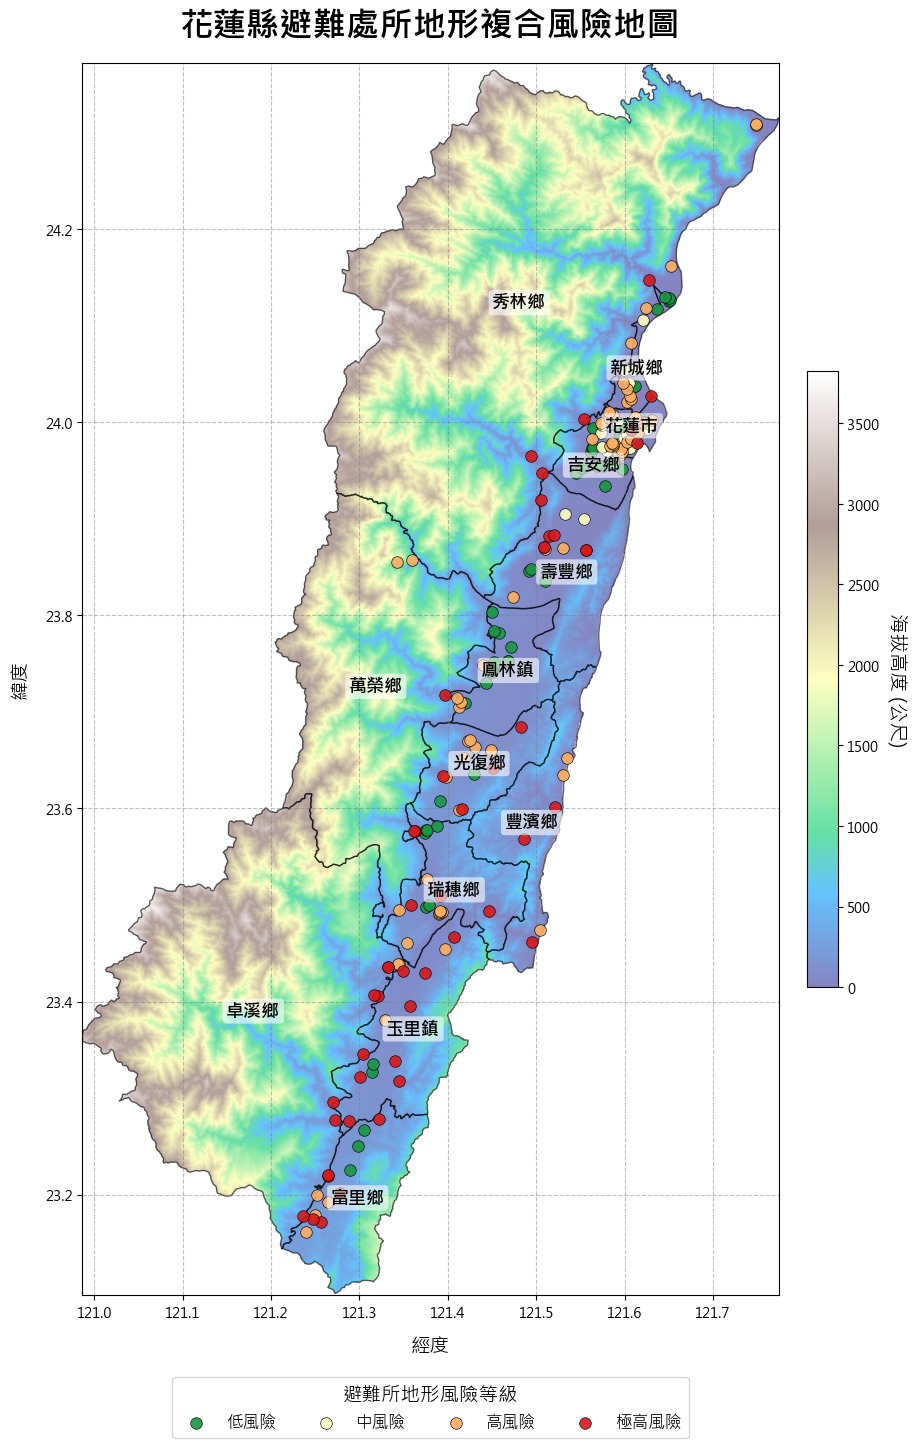

🎉 視覺化作業排版更新完成！


In [ ]:

# --- 解決 matplotlib 中文顯示問題 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Arial Unicode MS', 'Noto Sans TC']
plt.rcParams['axes.unicode_minus'] = False  
# -----------------------------------

print("=== Cell 8：繪製地形複合風險地圖 (排版升級版) ===")

# (若剛剛已經跑過重新投影，這段會稍微花一點點時間，請耐心等候)
print("[1/5] 檢查與獲取經緯度投影資料...")
dem_rx = rioxarray.open_rasterio(dem_path)
dem_gps = dem_rx.rio.reproject("EPSG:4326")
shelters_gps = shelters_final.to_crs("EPSG:4326")
hualien_gps = townships_gdf[townships_gdf['COUNTYNAME'] == '花蓮縣'].to_crs("EPSG:4326")

# 1. 設定地圖大小與比例
fig, ax = plt.subplots(figsize=(12, 16))

# 2. 獲取重新投影後 DEM 的地理範圍
dem_bounds_gps = dem_gps.rio.bounds()
extents_gps = [
    dem_bounds_gps[0], dem_bounds_gps[2], # Lon min, Lon max
    dem_bounds_gps[1], dem_bounds_gps[3]  # Lat min, Lat max
]

# 3. 繪製 DEM 彩色高程背景圖
print("[2/5] 繪製彩色地形高程背景...")
dem_array_gps = dem_gps.values[0]
nodata_val_gps = dem_gps.rio.nodata
dem_masked_gps = np.where(dem_array_gps == nodata_val_gps, np.nan, dem_array_gps)

# 繪製 DEM (vmin=0 處理海平面)
im_dem = ax.imshow(dem_masked_gps, cmap='terrain', extent=extents_gps, origin='upper', alpha=0.6, vmin=0, vmax=np.nanmax(dem_masked_gps))

# 👉 【修改 5】：新增海拔分層設色的圖例 (Colorbar)
cbar = fig.colorbar(im_dem, ax=ax, shrink=0.5, pad=0.03)
cbar.set_label('海拔高度 (公尺)', fontsize=14, rotation=270, labelpad=20)

# 4. 疊加行政區劃界
print("[3/5] 疊加鄉鎮市區界邊線與標籤...")
hualien_gps.plot(edgecolor='black', facecolor='none', linewidth=1.0, alpha=0.6, ax=ax)

# 加行政區名稱標籤 (TOWNNAME)
for idx, row in hualien_gps.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, 
        s=row['TOWNNAME'], 
        fontsize=13, 
        fontweight='bold', 
        c='black', 
        ha='center', va='center',
        # 👉 【修改 4】：設定 zorder=20 確保在最上層，並加上半透明白底避免與點位或地形混淆
        zorder=20,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2, boxstyle='round,pad=0.2')
    )

# 5. 繪製避難所風險點位
print("[4/5] 繪製避難所風險點位...")
risk_cmap_colors = {
    '極高風險': '#d7191c',
    '高風險': '#fdae61',  
    '中風險': '#ffffbf',  
    '低風險': '#1a9641'   
}
risk_order = ['低風險', '中風險', '高風險', '極高風險']

for risk in risk_order:
    data_points = shelters_gps[shelters_gps['risk_level'] == risk]
    if len(data_points) > 0:
        ax.scatter(
            data_points.geometry.x, 
            data_points.geometry.y, 
            c=risk_cmap_colors[risk], 
            label=risk,
            s=70, edgecolor='black', linewidths=0.5, alpha=0.9, 
            zorder=10 # 點位在 10，文字標籤在 20，所以文字會在點位上方
        )

# 6. 地圖裝飾 (標題、座標軸、圖例)
# 👉 【修改 1】：移除標題的 WGS84
ax.set_title("花蓮縣避難處所地形複合風險地圖", fontsize=24, fontweight='bold', pad=20)

# 👉 【修改 2】：X、Y 座標說明只保留經緯度
ax.set_xlabel("經度", fontsize=14, labelpad=10)
ax.set_ylabel("緯度", fontsize=14, labelpad=10)

handles, labels = ax.get_legend_handles_labels()
order_map = {label: i for i, label in enumerate(risk_order)}
sorted_indices = sorted(range(len(labels)), key=lambda k: order_map.get(labels[k], 99))

# 👉 【修改 3】：改變 loc 錨點並微調 bbox_to_anchor，確保圖例掛在 X 軸下方不重疊
ax.legend(
    [handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], 
    title="避難所地形風險等級", title_fontsize=14, fontsize=12, 
    loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=4, frameon=True
)

ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# 7. 儲存圖片
png_filename_final = 'terrain_risk_map.png'
print(f"\n正在儲存圖片至 '{png_filename_final}'...")
# bbox_inches='tight' 會自動計算邊界，確保外掛的圖例和 Colorbar 都不會被切掉
plt.savefig(png_filename_final, dpi=300, bbox_inches='tight', facecolor='white')

# 預覽圖片
plt.show()

print("🎉 視覺化作業排版更新完成！")